In [2]:
import numpy as np
import utils 
import pandas as pd 
from sklearn.impute import * 
import causallearn
import networkx as nx


# 1. Generate Data and Structural Causal Graph

In [3]:
utils.generate_full_data(10000, True, "test2")
data = np.loadtxt("./gen_data/test2.csv", delimiter = ",")

In [4]:
data

array([[ 0.54396319,  0.49509806,  1.98689755, -1.41083194],
       [ 2.05145586,  4.39809494,  7.69244519, -7.36580172],
       [ 2.35539105,  3.82138633,  7.05929309, -7.54084951],
       ...,
       [ 1.19383696,  1.75206345,  5.4801315 , -5.16760493],
       [ 2.39342332,  3.51360715,  9.01714089, -8.86387484],
       [ 0.05523076,  0.24012343,  2.26474391, -1.64352341]])

In [5]:
import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(["A", "B", "C", "D"])
G.add_edges_from([("A","B"), ("A", "C"), ("C", "D")])



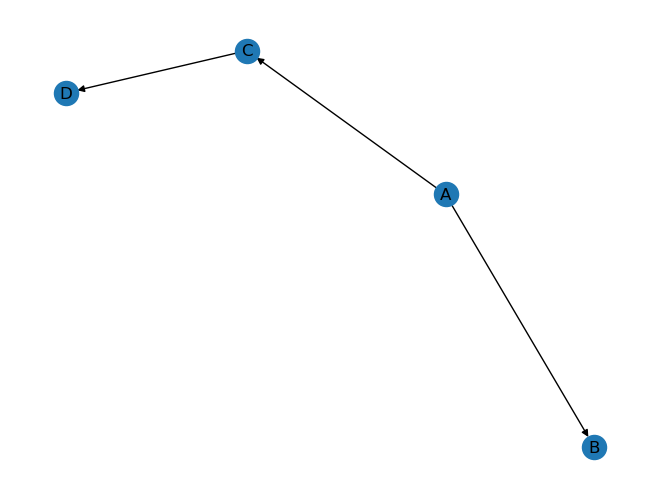

In [6]:
nx.draw(G, with_labels = True)

# 2. Induce Missing Data 

Here I induce the missing data MCAR with a 20% prob of being missing completely at random 

In [ ]:
# data_missing = utils.v_induce_missing_data(data, 0.2) 
# # rename to induce missing data on 27.6 
data_missing = utils.induce_missing_data(data, 0.2)

In [8]:
data_missing

array([[None, 0.49509806067667206, 1.9868975478530342,
        -1.4108319411401862],
       [2.0514558558067537, None, 7.692445185665191, -7.3658017233523285],
       [2.355391047827078, 3.821386334514412, 7.05929308501381, None],
       ...,
       [None, 1.7520634496389338, None, None],
       [2.3934233244449308, None, 9.01714088571068, -8.86387484091244],
       [0.05523075946523759, 0.2401234282235573, 2.2647439097558477,
        -1.6435234125867764]], dtype=object)

# 3. Impute Missing Data 

In [9]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="mean")

data_imputed = imp.fit_transform(data_missing)

# 4. Fit Structural Causal Model 

In [10]:
from causallearn.search.ConstraintBased.PC import pc

cg_imp = pc(data_imputed, 0.05, "fisherz")

  0%|          | 0/4 [00:00<?, ?it/s]

Green: undirected; Blue: directed; Red: bi-directed



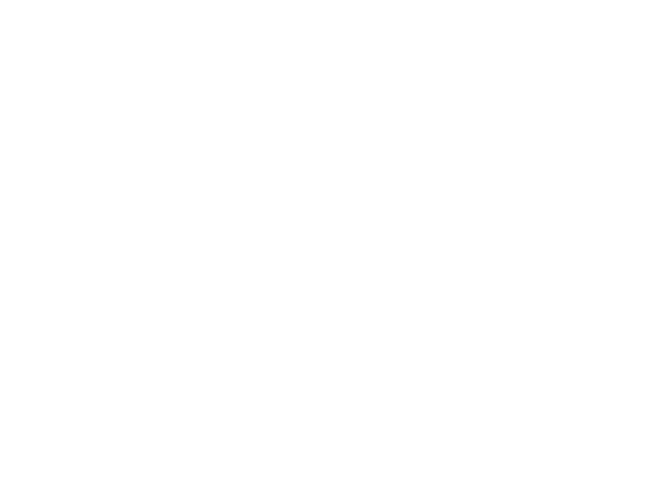

In [11]:
cg_imp.draw_nx_graph()

  0%|          | 0/4 [00:00<?, ?it/s]

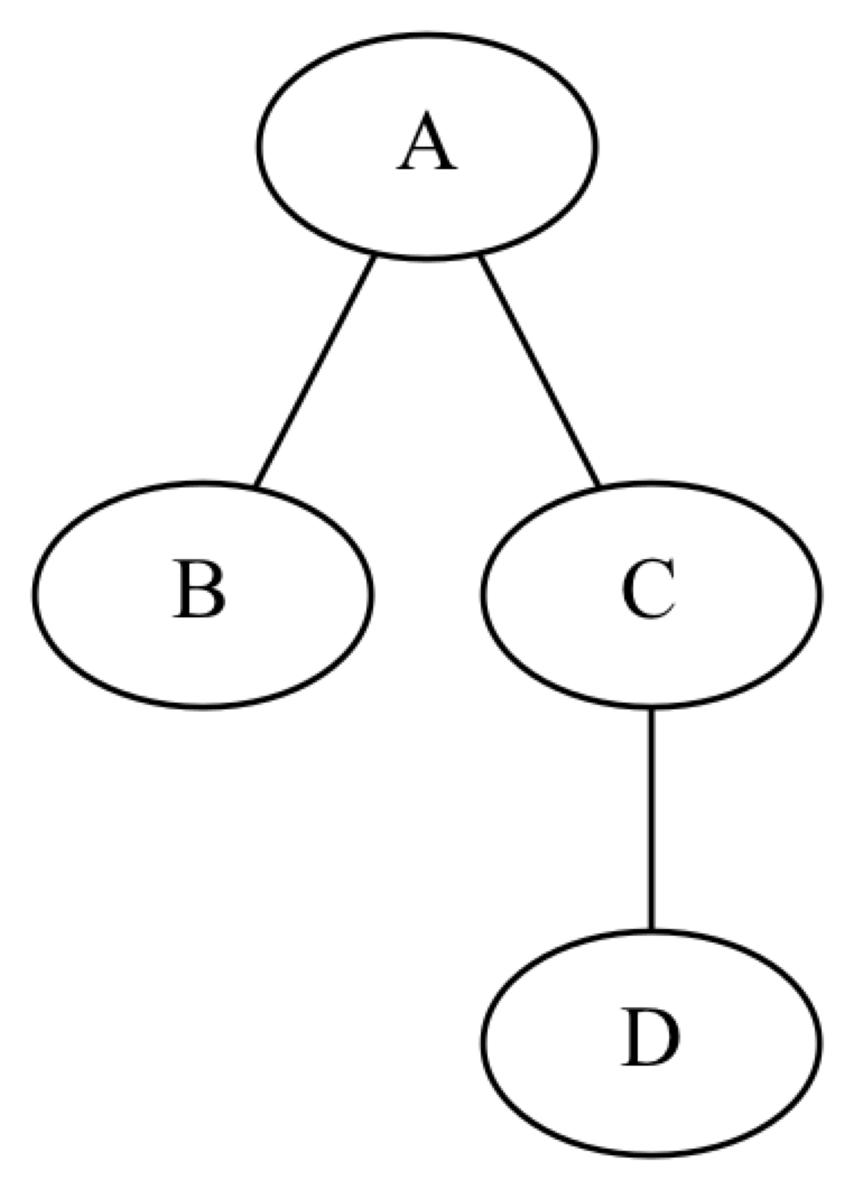

In [12]:
cg = pc(data, 0.05, "fisherz")
cg.draw_pydot_graph(labels=["A","B","C","D"])

# 5. Compare to Original SCM 

In [13]:
cg_imp.G.graph

array([[ 0, -1, -1, -1],
       [-1,  0, -1, -1],
       [-1, -1,  0, -1],
       [-1, -1, -1,  0]])

In [14]:
cg.G.graph

array([[ 0, -1, -1,  0],
       [-1,  0,  0,  0],
       [-1,  0,  0, -1],
       [ 0,  0, -1,  0]])

In [15]:
cg.G.graph == cg_imp.G.graph

array([[ True,  True,  True, False],
       [ True,  True, False, False],
       [ True, False,  True,  True],
       [False, False,  True,  True]])

In [17]:
cg_imp.to_nx_graph() # first need to convert them so that cg.nx_grpah is not none
cg.to_nx_graph()
nx.graph_edit_distance(cg_imp.nx_graph, cg.nx_graph)

6.0

In [18]:
cg.to_nx_graph()

In [19]:
print(cg.nx_graph)

DiGraph with 4 nodes and 6 edges
